# Lesson 2: Image Arithmetic

Since an image is a 2D array of numbers (Lesson 1), basic arithmetic can be used to edit the image: add a constant to brighten, subtract to darken, blend two images by weighted averaging, etc. This lesson shows some examples, highlighting an important subtlety: when images are stored as 8-bit unsigned integers, *how* you do the arithmetic matters.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Brightening: add a constant

A pixel's value represents the amount of light, so adding a positive constant to every pixel should brighten the whole image. Let's try it directly with NumPy.

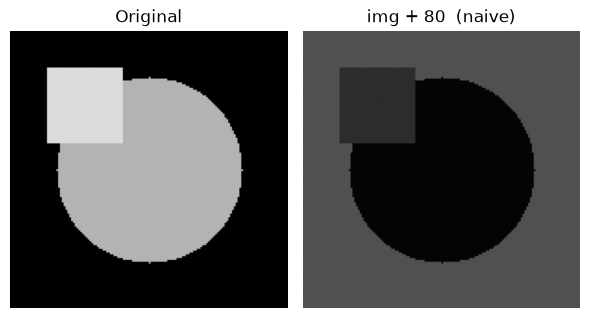

In [2]:
img = np.zeros((150, 150), dtype=np.uint8)
cv2.circle(img, (75, 75), 50, 180, -1)

brightened_naive = img + np.uint8(80)

fig, axes = plt.subplots(1, 2, figsize=(6, 3.5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[1].imshow(brightened_naive, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('img + 80  (naive)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

Look closely at the circle: instead of becoming *brighter*, it actually became *darker*. Something has gone wrong.

## The problem: `uint8` overflow

An 8-bit unsigned integer can only represent 0 to 255. Therefore, `220 + 80 = 300` yields a result that does not fit into the single byte. NumPy's `uint8` arithmetic **wraps around** (like a car odometer rolling over), silently computing `300 mod 256 = 44` instead of **clamping** at 255. This is exactly the same fixed-width overflow behavior any low-level integer type has; NumPy just applies it silently, with no warning.

In [3]:
sample_values = np.array([200, 250, 220])

print('original values:      ', sample_values)
print('naive (uint8) + 80:   ', sample_values.astype(np.uint8) + np.uint8(80), '  <- wrapped around, not clamped!')
print('what we actually want:', np.clip(sample_values + 80, 0, 255))

original values:       [200 250 220]
naive (uint8) + 80:    [24 74 44]   <- wrapped around, not clamped!
what we actually want: [255 255 255]


## The fix: saturating arithmetic

OpenCV's arithmetic functions (`cv2.add`, `cv2.subtract`, ...) use **saturating** arithmetic: results are clamped to the valid range (0-255 for `uint8`) rather than wrapping. This is almost always what you actually want.

pixel value, original:   220
pixel value, naive (wrapped):     44
pixel value, cv2.add (saturated): 255


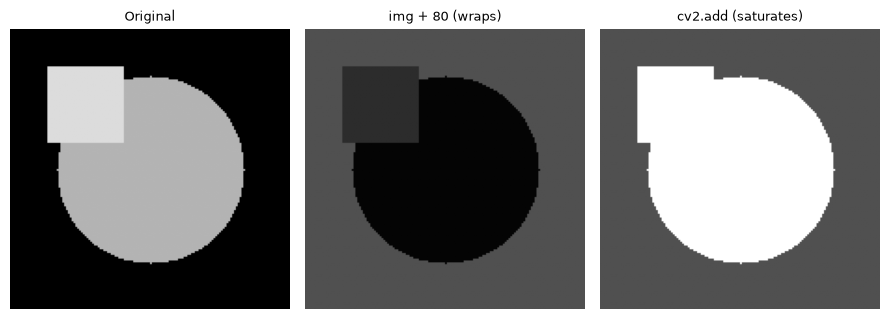

In [4]:
brightened_saturated = cv2.add(img, 80)

print('pixel value, original:  ', img[40, 40])
print('pixel value, naive (wrapped):    ', brightened_naive[40, 40])
print('pixel value, cv2.add (saturated):', brightened_saturated[40, 40])

fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
for ax, im, title in zip(axes, [img, brightened_naive, brightened_saturated],
                          ['Original', 'img + 80 (wraps)', 'cv2.add (saturates)']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

With saturation, every pixel gets brighter or stays at the maximum &mdash; never wraps around to become darker. The same idea applies to `cv2.subtract` at the bottom end (clamped at 0 instead of wrapping to a large positive number).

## Brightening only part of an image, with a mask

Often you want to adjust brightness selectively &mdash; e.g., lighten a foreground subject without touching the background. Given a binary mask (from thresholding or segmentation), only copy the brightened result where the mask is set.

In [ ]:
photo = cv2.imread('../img/sheepdog.jpg')
foreground_mask = cv2.imread('../img/sheepdog_mask.png', cv2.IMREAD_GRAYSCALE)

fully_brightened = cv2.add(photo, np.full_like(photo, 60))
result = photo.copy()
result[foreground_mask > 0] = fully_brightened[foreground_mask > 0]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, im, title in zip(axes,
                          [cv2.cvtColor(photo, cv2.COLOR_BGR2RGB), foreground_mask, cv2.cvtColor(result, cv2.COLOR_BGR2RGB)],
                          ['Original', 'Mask (foreground)', 'Only foreground brightened']):
    ax.imshow(im, cmap='gray' if im.ndim == 2 else None)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'dog pixel (BGR), before -> after:   {photo[119, 160]} -> {result[119, 160]}')
print(f'grass pixel (BGR), before -> after: {photo[5, 5]} -> {result[5, 5]}')

<p class="image-attribution">Image source: <a href="https://commons.wikimedia.org/wiki/File:Dog_walking_sideview_grass.JPG" target="_blank" rel="noopener">Wikimedia Commons</a></p>

`cv2.add` (and several other OpenCV functions) also accept a `mask` argument directly, which does exactly this select-and-copy in one call: `cv2.add(photo, 60, mask=foreground_mask)` &mdash; which only writes into the masked region, leaving the rest of the destination untouched.

## Blending two images

A weighted sum of two images &mdash; a **cross-dissolve** &mdash; is the same saturating arithmetic, generalized: `cv2.addWeighted(a, alpha, b, beta, gamma)` computes `a*alpha + b*beta + gamma`, saturated.

In [ ]:
img_a = cv2.imread('../img/sheepdog.jpg')
img_b = cv2.imread('../img/lhasa_apso.jpg')
img_b = cv2.resize(img_b, (img_a.shape[1], img_a.shape[0]))  # match dimensions for addWeighted

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for ax, alpha in zip(axes, [0.0, 0.25, 0.5, 0.75, 1.0]):
    blended = cv2.addWeighted(img_a, 1 - alpha, img_b, alpha, 0)
    ax.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
    ax.set_title(f'alpha={alpha}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

<p class="image-attribution">Image sources: <a href="https://commons.wikimedia.org/wiki/File:Dog_walking_sideview_grass.JPG" target="_blank" rel="noopener">Wikimedia Commons</a>, <a href="https://commons.wikimedia.org/wiki/File:Lhasaapso.jpg" target="_blank" rel="noopener">Wikimedia Commons</a></p>

## Difference imaging

Subtracting two images (with an absolute value, so both directions of change matter equally) highlights exactly what's different between them &mdash; the basis of simple motion/change detection, and something we'll reuse when comparing reconstructions against ground truth in later lessons.

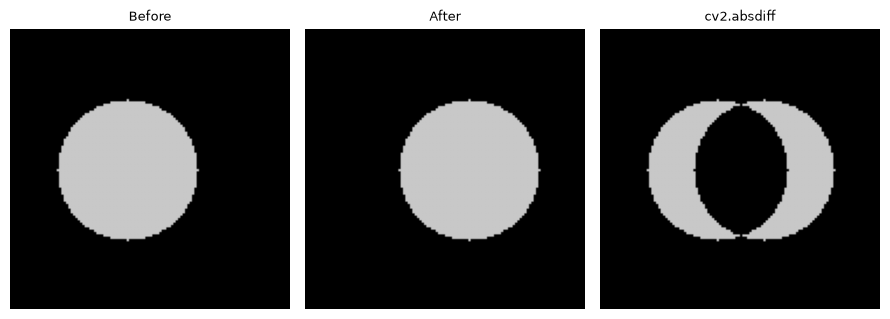

In [7]:
before = np.zeros((120, 120), dtype=np.uint8)
cv2.circle(before, (50, 60), 30, 200, -1)

after = np.zeros((120, 120), dtype=np.uint8)
cv2.circle(after, (70, 60), 30, 200, -1)  # the circle moved

difference = cv2.absdiff(before, after)

fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
for ax, im, title in zip(axes, [before, after, difference], ['Before', 'After', 'cv2.absdiff']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

The difference image is zero everywhere nothing changed, and bright exactly where the circle used to be or now is &mdash; except for the overlapping middle region, where the circle is present in both frames.

### Exercise

1. Predict, then check, what `cv2.subtract(img, 150)` does to a pixel whose value is `100` &mdash; does it wrap around like the naive NumPy addition did, or saturate?
2. Use `cv2.add` with its `mask` argument directly (instead of manually copying with boolean indexing as done above) to reproduce the masked-brightening result, and confirm the two approaches give identical output.
3. `cv2.addWeighted` does not require `alpha + beta` to sum to 1 (the `gamma` term is added on top of both). Try `cv2.addWeighted(img_a, 1.0, img_b, 1.0, 0)` (a plain saturating sum, not a blend) and describe what changes about the result compared to `alpha=0.5`.